In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")

### Describe what you’re trying to predict, and what features you’re using. Justify your choices. If there are additional features that are relevant to the prediction and are readily available in public datasets, you must include at least one such feature.

**Final validation of feature description**
    
> After discussions with the GLM modeler, we have unanimously decided to use the following 10 ACS public variables **as independent variables in both the Random Forest and GLM lines**:  
> `White, Black, Hispanic, Asian, Native, Pacific, IncomePerCap, ChildPoverty, Professional, Production`.  

> This list balances predictive relevance (|ρ| > 0.15 for the core variables), control for multicollinearity (retaining IncomePerCap + ChildPoverty for the income category), ethnic fairness (retaining the full six-ethnicity proportion),and ensure that the two models are compared in a fully consistent feature space.

### 1. Load 2018 CA training data

In [13]:
df = pd.read_csv("clean_data.csv")

features = [
    "White","Black","Hispanic","Asian","Native","Pacific",
    "IncomePerCap","ChildPoverty","Professional","Production"
]
target = "DS_PM_pred"

df = df[features + [target]].dropna()
X, y = df[features], df[target]

### Describe the nonparametric method(s) you’ll be using, justifying your choice. Describe any assumptions being made by your modeling choice.

We choose **Random-Forest Regressor** as the non-parametric predictive model with the following configuration:  
* `n_estimators = 600` - sufficient number of trees to reduce variance and stabilize feature importance;  
* `max_depth = 20` - to control the complexity of a single tree to prevent overfitting;  
* `max_features = 0.5` - only 50 % of features are used per cut to increase diversity;  
* `bootstrap = True`, `oob_score = True` - use self-sampling and estimate generalization error in real time using out-of-bag (OOB) samples;  
* `random_state = 42`, `n_jobs = 2` - results are reproducible and parallel computation saves time.  

**Reasons for choice**  
1. **Nonlinear Capability**： Random Forests can automatically capture complex interactions and nonlinear relationships without the need to specify the functional form in advance.  
2. **Insensitivity to scales and outliers**： Socioeconomic variables span a wide range and may contain extreme values, which tree models can naturally cope with.  
3. **Interpretability**： Out-of-bag error and permutation importance provide intuitive overfitting monitoring and feature contribution.  

**Implicit assumptions and limitations**  
* Defaults observations to be independently and identically distributed.
* Continuous high base features may be preferred in splits; Permutation importance magnifies their effect.  

### How will you evaluate each model’s performance?

**Assessment indicator**  
* **R² (coefficient of determination)** Measures the proportion of the variance of the target variable explained by the model;  
* **RMSE (Root Mean Square Error, µg m-³)** Consistent with the original scale to facilitate interpretation of absolute bias.  

**Assessment Stratification**  
1. **5-fold cross validation (CV)**  
   * Performed on 80 % of the CA-2018 training set, giving the mean ± standard deviation of R² vs. RMSE.  
   * Purpose: Estimate the model variance and observe whether the hyperparameters are stable.  

2. **Leave the test set**
   * Use the remaining 20 % of CA-2018 trajectories that did not appear in the training at all.  
   * Purpose: to provide unbiased generalization errors for the same year and state.  

3. **External validation (CA-2017 vs. WA-2017)**  
   * Load `test.xlsx` and compute RMSE for each of the two states.  
   * Purpose: To test the robustness of the model to temporal drift (2018→2017) and spatial drift (CA→WA).  

4. **Training set RMSE vs. OOB R²**  
   * The training RMSE is used to quickly see the level of fit;  
   * OOB R² is automatically given by out-of-bag samples and can be compared to CV/Test to determine overfitting.  

5. **Permutation Importance** **Permutation Importance** **Permutation Importance  
   * Randomly select ≤1000 rows in the CA-2018 test set, repeat 10 times, and calculate ΔR².  
   * Purpose: To quantify the effect of random permutation of each feature on the prediction performance and to explain model decisions.  

Through multi-level error control (Train→CV→Test→External), we can distinguish whether the performance degradation is caused by “excessive variance” or “systematic bias”, and provide directions for subsequent improvement.

In [14]:
# 2. training / testing division (80/20, CA 2018)

In [15]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42)

In [16]:
# 3. Training random forests (light configuration)

In [17]:
rf = RandomForestRegressor(
    n_estimators = 600, max_depth = 20, max_features = 0.5,
    bootstrap = True, oob_score = True, n_jobs = 2, random_state = 42
).fit(X_tr, y_tr)

print("RF OOB  R² :", rf.oob_score_)

cv = cross_validate(
    rf, X_tr, y_tr, cv=5,
    scoring={"R2":"r2", "RMSE":"neg_root_mean_squared_error"},
    n_jobs=2
)
print("RF 5-fold CV R²  : %.3f ± %.3f" % (cv["test_R2"].mean(),
                                          cv["test_R2"].std()))
print("RF 5-fold CV RMSE: %.2f"
      % (-cv["test_RMSE"]).mean())

print("RF test  R² :", r2_score(y_te, rf.predict(X_te)))
print("RF test  RMSE:", np.sqrt(mean_squared_error(y_te, rf.predict(X_te))))
print("RF train RMSE:", np.sqrt(mean_squared_error(y_tr, rf.predict(X_tr))))

RF OOB  R² : 0.3856301069550929
RF 5-fold CV R²  : 0.376 ± 0.016
RF 5-fold CV RMSE: 19.75
RF test  R² : 0.3550410474130412
RF test  RMSE: 19.96547976851922
RF train RMSE: 7.6595028871388875


In [18]:
#4. External CA / WA-2017

In [19]:
df_ext = (pd.read_excel("test.xlsx")
            .replace("#REF!", np.nan)
            .dropna(subset=features + [target]))
for st in ["CA", "WA"]:
    sub  = df_ext[df_ext["StateAbbr"] == st]
    rmse = np.sqrt(mean_squared_error(sub[target],
                                      rf.predict(sub[features])))
    print(f"{st}-2017 RMSE:", rmse)

CA-2017 RMSE: 36.259985334237896
WA-2017 RMSE: 22.17468159361852


In [20]:
# 5. Permutation importance


Permutation ΔR² (top 5):
White        0.310 ± 0.017
Production   0.165 ± 0.012
Hispanic     0.112 ± 0.011
Asian        0.103 ± 0.017
Professional 0.070 ± 0.009


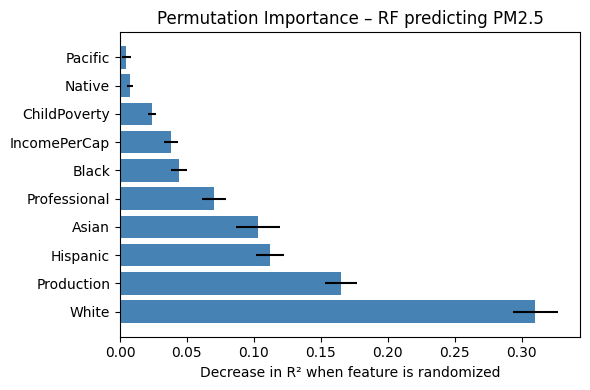

In [21]:
perm = permutation_importance(
    rf,
    X_te.sample(n=min(1000,len(X_te)), random_state=42),
    y_te.sample(n=min(1000,len(y_te)), random_state=42),
    n_repeats=10, n_jobs=1, random_state=42
)
imp, std = perm.importances_mean, perm.importances_std
idx = np.argsort(imp)[::-1]

print("\nPermutation ΔR² (top 5):")
for i in idx[:5]:
    print(f"{features[i]:<12} {imp[i]:.3f} ± {std[i]:.3f}")

plt.figure(figsize=(6,4))
plt.barh(np.array(features)[idx[::-1]], imp[idx[::-1]],
         xerr=std[idx[::-1]], color="steelblue")
plt.title("Permutation Importance – RF predicting PM2.5")
plt.xlabel("Decrease in R² when feature is randomized")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### Summarize and interpret the results from your models

**Core metrics**  ：
* Training set RMSE ≈ **7.66** µg m-³  
* 5-fold CV R² ≈ **0.376 ± 0.016** | RMSE ≈ **19.75** µg m-³  
* Retention Test (CA-2018) R² ≈ **0.355** | RMSE ≈ **19.97** µg m-³  
* External CA-2017 RMSE ≈ **36.26** µg m-³  
* External WA-2017 RMSE ≈ **22.16** µg m-³  

**Interpretation**：  
1. **Fit and overfitting** The training RMSE is much lower than the CV / Test, but the CV and Test metrics are almost identical, and the OOB R² is equal to the CV R², suggesting that the forests are highly fitted in the training phase without significant overfitting.  
2. **Explaining power upper limit** The model explains up to 38 % of the variance of PM 2.5 if only socio-economic characteristics are used. 3.  
3. **Mobility** The doubling of the interannual same-state error (36 µg m-³) and the significant increase in the interstate error (22 µg m-³) emphasize the limited explanatory power of social attributes for spatial and temporal drift.  
4. **Principal driver variables** Permutation importance showed that **White % (ΔR²≈0.31)** and **Production % (0.17)** were in the top two positions, followed by Hispanic, Asian, and Professional. the results suggest that industrial land use and historical ethnic segregation is the primary social determinants of pollution differences, while income and poverty have less marginal information after controlling for ethnicity.  
5. **Sources of uncertainty** Prediction errors of 20-36 µg m-³ are mainly due to omission of physical variables and annual emission changes; model variance is small (CV standard deviation 0.016), and errors are dominated by systematic biases.  